# Resumen
En el siguiente notebook se recopila la informacion del EDA realizado para la base de datos, a lo largo del notebook se establecieron 
comentarios donde se analizaron y concluyeron puntos importantes que voy a mencionar brevemente a continuacion:
    * Se calculan algunas variables como time_diff , se descompone la fecha en diferentes variables 
    * Se realiza un analisis de transacciones donde se encontraron algunos puntos importantes como :
        * 16969 reporte de transacciones sospechosas correspondinte al 0.16% del total de la base 
        * apartir de percentil 75% se realizan mas transacciones y un mayor monto dirario.
        * Adicionalmente se recocen los tres comercios unicos en relacion a las transacciones 
        * Las personas que tienen entre 5 y 9 cuentas tienen un mayor numero de transacciones

## Los resultados obtenidos los encontraran aca como resumen adicionalmente podran ver graficas a lo largo del contenido:
* De acuerdo a la desviacion estandar y al promedio podemos afirmar que los usuarios con mas cuentas tienen un comportamiento mas activo y tienen mas diferencias en sus transacciones
* En un paquete de 10.000.000 registros encontramos un promedio del 4% transacciones atipicas que se podrian revisar con mayor detalle aumentando el numero y validando la hipotesis generada anteriormente segun el comportamiento por numero de cuentas 

## Los comercios con mayor cantidad de anómalias:
* el comercio con mayor anomalias se conoce como "817d18cd3c31e40e9bff0566baae7758"
* Si comparamos los clientes que presetaron algunas anomalias en el análisis anterior se observa que a las 12 del dia y a 18 hores se concentra el mayor numero de transacciones anomalas , en los clientes con mayor numero de productos .
* Como recomendacion en un escenario real estas transacciones se deberían validar por topes o  complentar con configuraciones que permitan comporbar dicha alerta 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys 
# import scikitplot as skplt
import scipy.stats as stats
import pickle
from ydata_profiling import ProfileReport

In [2]:
os.chdir("C:/Users/sergi/Documents/Pruebas Técnicas/Nequi DS/Analisis_fraude/analisis-fraude/")

## EDA

In [3]:
file_path = "data/01_raw/sample_data_0006_part_00.parquet"

In [4]:
%%time
data = pd.read_parquet(file_path)
# Ajustar tipos de datos
data["transaction_amount"] = data["transaction_amount"].astype(float)
data["transaction_date"] = pd.to_datetime(data["transaction_date"])
# data = data.sample(n=10000, random_state=42)

CPU times: user 18.2 s, sys: 4.49 s, total: 22.7 s
Wall time: 23.2 s


In [5]:
# Convertir la columna de fechas a formato datetime
data['transaction_date'] = pd.to_datetime(data['transaction_date'])

# Extraer información temporal
data['year'] = data['transaction_date'].dt.year
data['month'] = data['transaction_date'].dt.month
data['day'] = data['transaction_date'].dt.day
data['day_of_week'] = data['transaction_date'].dt.dayofweek
data['is_weekend'] = data['day_of_week'].isin([5, 6])  # Sábado (5) y Domingo (6)

# Calcular la diferencia de tiempo entre transacciones para cada usuario
data = data.sort_values(by=['user_id', 'transaction_date'])
data['time_diff'] = data.groupby('user_id')['transaction_date'].diff().dt.total_seconds()

# Revisar las primeras filas con las nuevas variables
data.head()


,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,year,month,day,day_of_week,is_weekend,time_diff
10045125,838a8fa992a4aa2fb5a0cf8b15b63755,ecba8ff3dc6593175188301c8ae1ad03,1c9c7c96fcd19d2063bb47e01c5df998,2021-01-26 18:29:08,3fadf4b282c09463f16c6ebcc21c83eb,000002373d5835d0e53b78722424076f,29.722275,CREDITO,2021,1,26,1,False,NaN
10045126,838a8fa992a4aa2fb5a0cf8b15b63755,55c4b353af003307c4ce801c9592c873,1c9c7c96fcd19d2063bb47e01c5df998,2021-02-23 08:37:45,3fadf4b282c09463f16c6ebcc21c83eb,000002373d5835d0e53b78722424076f,71.333460,CREDITO,2021,2,23,1,False,2383717.0
10045127,838a8fa992a4aa2fb5a0cf8b15b63755,f7a743f69702e6ce077074a43550acee,1c9c7c96fcd19d2063bb47e01c5df998,2021-04-15 10:59:10,3fadf4b282c09463f16c6ebcc21c83eb,000002373d5835d0e53b78722424076f,23.777820,CREDITO,2021,4,15,3,False,4414885.0
1153432,075d178871d8d48502bf1f54887e52fe,d531b1fdca8cf53ad20525e60576323f,24f755d1de59e3983ebfaf47f760cc2f,2021-03-10 11:30:55,10e6890a86c790e6af17dc99f391a658,000004f4a6f3ac93f454a5dc04b2a252,594.445501,CREDITO,2021,3,10,2,False,NaN
8043799,817d18cd3c31e40e9bff0566baae7758,3c5e7b1b155417152b9ef87763eed181,80a2ee488271394873b4f5d993ca99b6,2021-11-05 18:48:15,10e6890a86c790e6af17dc99f391a658,000004f4a6f3ac93f454a5dc04b2a252,178.333650,DEBITO,2021,11,5,4,False,20762240.0


### Se crean algunas variables que permiten mejorar la interpretacion del problema como :
    * time_diff : calcula la diferencia de tiempo entre transacciones 
    * se descompone la columna fecha en año . mes ,dia 

## Informacion general

In [6]:
# Calcular métricas solicitadas
unique_merchants_count = data['merchant_id'].nunique()
unique_clients_count = data['user_id'].nunique()
debit_accounts_count = data[data['transaction_type'] == "DEBITO"]['account_number'].nunique()
credit_accounts_count = data[data['transaction_type'] == "CREDITO"]['account_number'].nunique()



In [7]:
summary_table = pd.DataFrame({
    'Metric': [
        'Unique Merchants',
        'Unique Clients',
        'Debit Accounts',
        'Credit Accounts'
    ],
    'Count': [
        unique_merchants_count,
        unique_clients_count,
        debit_accounts_count,
        credit_accounts_count
    ]
})
summary_table

,Metric,Count
0,Unique Merchants,3
1,Unique Clients,1948844
2,Debit Accounts,1378958
3,Credit Accounts,852836


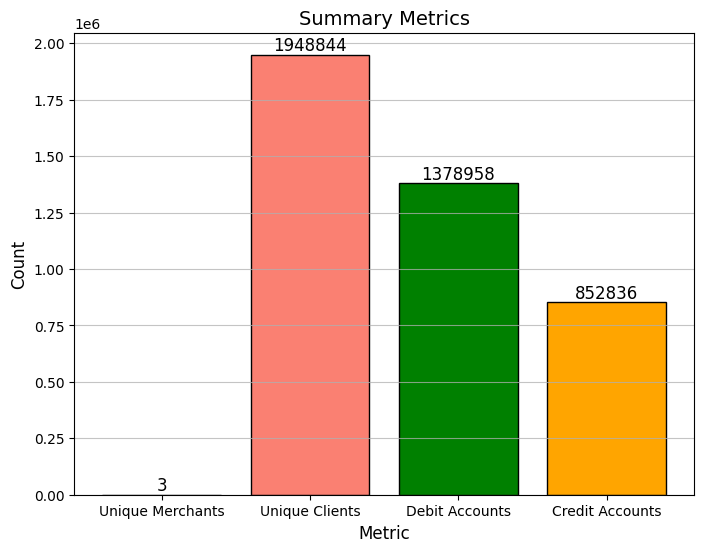

In [8]:
# Graficar las métricas con etiquetas de valor
plt.figure(figsize=(8, 6))
bars = plt.bar(summary_table['Metric'], summary_table['Count'], color=['skyblue', 'salmon', 'green', 'orange'], edgecolor='k')

# Agregar etiquetas con los valores
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.title('Summary Metrics', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

## Análisis de las transacciones

In [9]:
# Agrupamiento por año y mes
data['year_month'] = data['transaction_date'].dt.to_period('M')
year_month_summary = data.groupby('year_month').size().reset_index(name='Transaction Count')


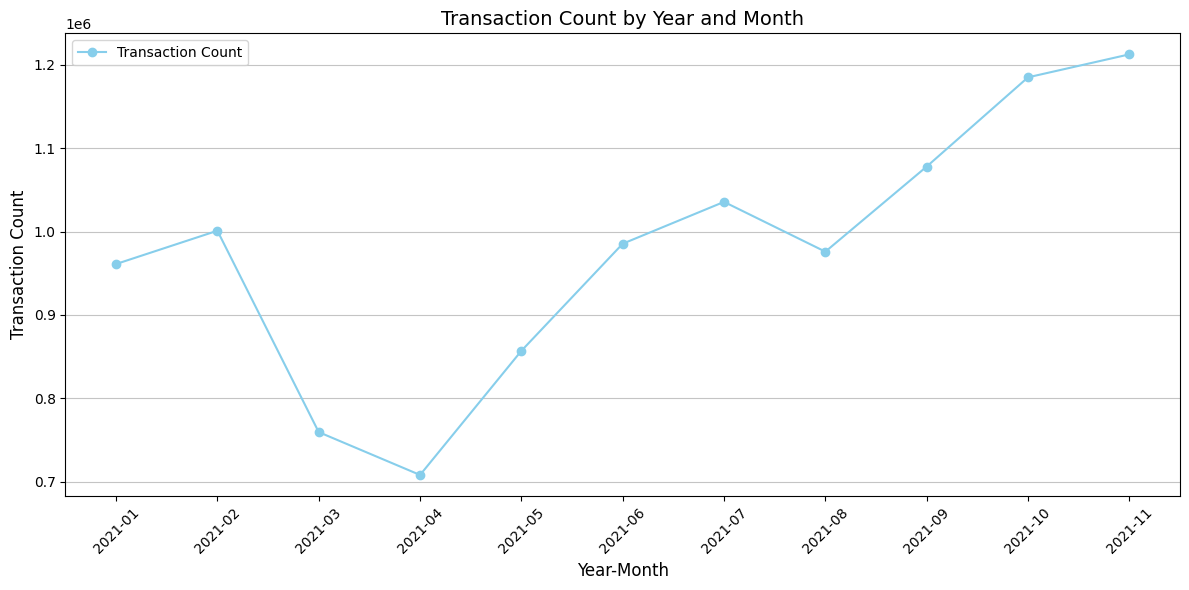

In [10]:
# Graficar el conteo de transacciones por año y mes
plt.figure(figsize=(12, 6))
plt.plot(year_month_summary['year_month'].astype(str), year_month_summary['Transaction Count'], marker='o', color='skyblue', label='Transaction Count')

plt.title('Transaction Count by Year and Month', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

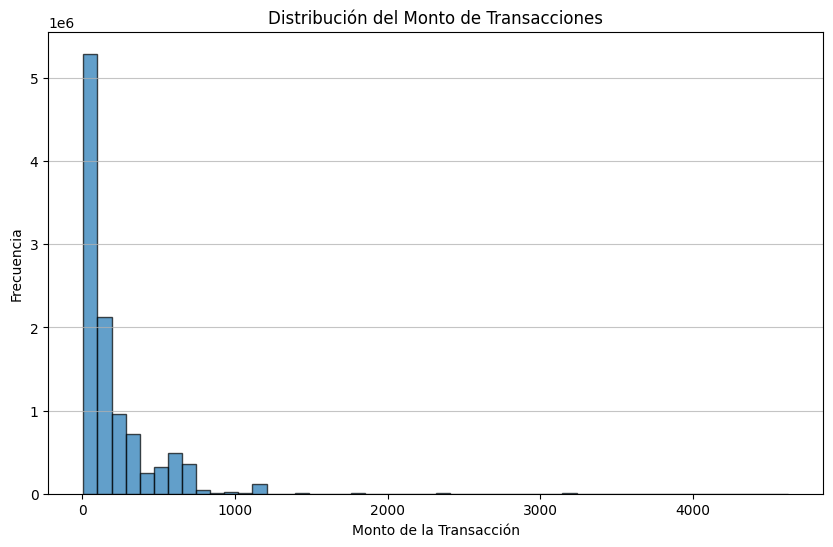

In [11]:
# Estadísticas descriptivas de transaction_amount
stats = data['transaction_amount'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

# Visualizar la distribución del monto de las transacciones
plt.figure(figsize=(10, 6))
plt.hist(data['transaction_amount'], bins=50, alpha=0.7, edgecolor='k')
plt.title('Distribución del Monto de Transacciones')
plt.xlabel('Monto de la Transacción')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()



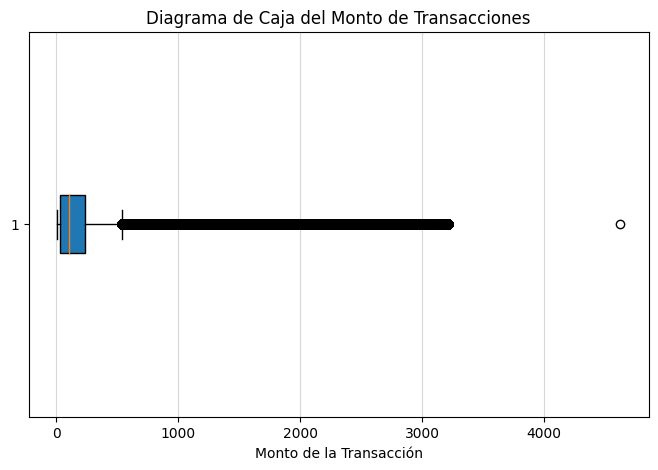

In [12]:
# Diagrama de caja para detectar valores atípicos
plt.figure(figsize=(8, 5))
plt.boxplot(data['transaction_amount'], vert=False, patch_artist=True)
plt.title('Diagrama de Caja del Monto de Transacciones')
plt.xlabel('Monto de la Transacción')
plt.grid(axis='x', alpha=0.5)
plt.show()


In [13]:
# Mostrar estadísticas descriptivas
stats


count    1.075842e+07
mean     1.913974e+02
std      2.408633e+02
min      5.944455e+00
25%      3.566673e+01
50%      1.070002e+02
75%      2.377782e+02
90%      5.706677e+02
95%      7.133346e+02
max      4.624786e+03
Name: transaction_amount, dtype: float64

In [15]:
# Clasificar montos de transacciones como 'Bajo', 'Medio', 'Alto'
data['transaction_class'] = pd.cut(
    data['transaction_amount'],
    bins=[data['transaction_amount'].min(), stats['50%'], stats['75%'], stats['max']],
    labels=['Bajo', 'Medio', 'Alto'],
    include_lowest=True
)


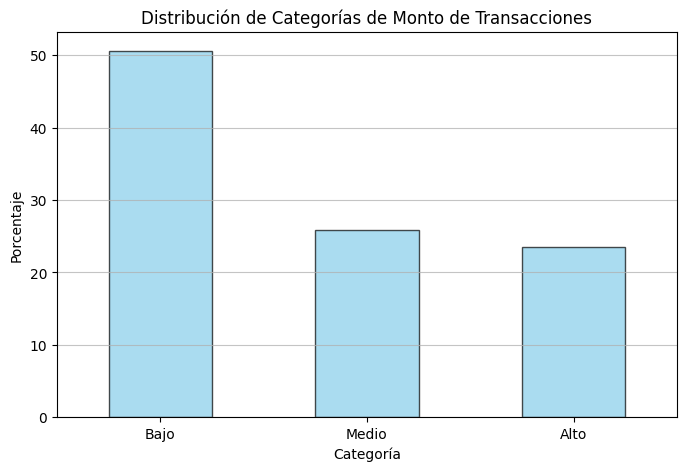

In [16]:

# Visualizar la distribución de estas categorías
class_distribution = data['transaction_class'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
class_distribution.plot(kind='bar', alpha=0.7, color='skyblue', edgecolor='k')
plt.title('Distribución de Categorías de Monto de Transacciones')
plt.xlabel('Categoría')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()




In [17]:
# Mostrar distribución porcentual
class_distribution

transaction_class
Bajo     50.636859
Medio    25.920502
Alto     23.442638
Name: proportion, dtype: float64

### Distribucion transaccional
LA mayoría de las transacciones tienen montos basjos y las altas corresponden a un 23% por lo tanto podrín ser mas relevantes a la hora de buscar un riesgo 

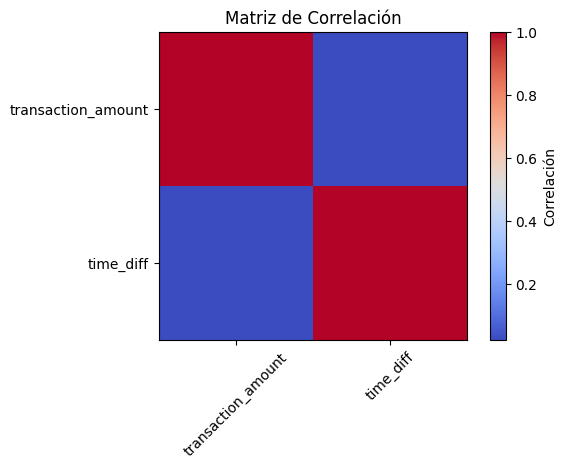

In [12]:
# Análisis de correlación entre variables numéricas
correlation_matrix = data[['transaction_amount', 'time_diff']].corr()

# Visualizar matriz de correlación
plt.figure(figsize=(6, 4))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlación')
plt.xticks(range(correlation_matrix.shape[0]), correlation_matrix.columns, rotation=45)
plt.yticks(range(correlation_matrix.shape[1]), correlation_matrix.columns)
plt.title('Matriz de Correlación')
plt.show()



In [21]:
# Explorar posibles patrones de fraccionamiento transaccional
# Agrupación por usuario y ventana de 24 horas
data['transaction_date_floor'] = data['transaction_date'].dt.floor('D')
user_grouped = data.groupby(['user_id', 'transaction_date_floor'])['transaction_amount']

# Suma y cuenta de transacciones por usuario en cada día
user_summary = user_grouped.agg(['sum', 'count']).reset_index()
user_summary.rename(columns={'sum': 'daily_amount', 'count': 'transaction_count'}, inplace=True)

# Mostrar las primeras filas del resumen por usuario
user_summary.head()


,user_id,transaction_date_floor,daily_amount,transaction_count
0,000002373d5835d0e53b78722424076f,2021-01-26,29.722275,1
1,000002373d5835d0e53b78722424076f,2021-02-23,71.333460,1
2,000002373d5835d0e53b78722424076f,2021-04-15,23.777820,1
3,000004f4a6f3ac93f454a5dc04b2a252,2021-03-10,594.445501,1
4,000004f4a6f3ac93f454a5dc04b2a252,2021-11-05,178.333650,1


In [27]:
accounts_per_user = data.groupby('user_id')['account_number'].nunique()
# Calcular el número de transacciones por user_id
transactions_per_user = data.groupby('user_id')['_id'].count()

# Asociar el número de cuentas por user_id
accounts_and_transactions = accounts_per_user.to_frame(name='num_accounts').join(
    transactions_per_user.to_frame(name='num_transactions')
)

# Calcular el promedio de transacciones para usuarios con 1 o 2 cuentas
avg_transactions = accounts_and_transactions[accounts_and_transactions['num_accounts'].isin([1, 2,3,4,5,6,7,8,9,10,12])].groupby('num_accounts')['num_transactions'].mean()

avg_transactions


num_accounts
1       5.496378
2      12.571237
3      36.077922
4      34.153846
5     119.000000
6     209.600000
7     533.166667
8     127.750000
9     644.000000
10     58.000000
Name: num_transactions, dtype: float64

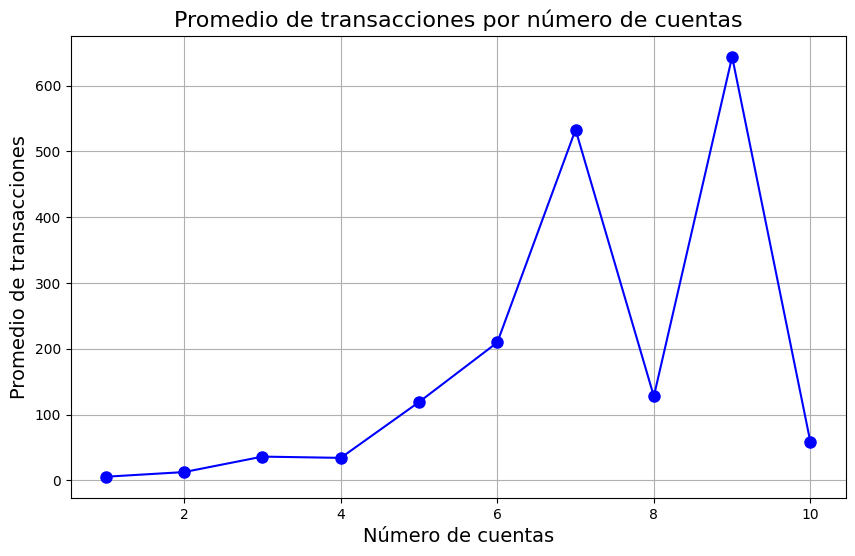

In [29]:
# Graficar promedio de transacciones segun el numero de tarjtas
plt.figure(figsize=(10, 6))
plt.plot(avg_transactions.index, avg_transactions.values, marker='o', color='b', linestyle='-', markersize=8)
plt.title("Promedio de transacciones por número de cuentas", fontsize=16)
plt.xlabel("Número de cuentas", fontsize=14)
plt.ylabel("Promedio de transacciones", fontsize=14)
plt.grid(True)
plt.show()

In [19]:
users_with_multiple_accounts = accounts_per_user[accounts_per_user > 2]
users_with_multiple_accounts

user_id
002cf616481a736ed283e78bdced945f    3
02ec56bf3d8f35adb6a76b55c1d69e9d    3
03f9ae82fdec97db574d4f80b220a304    3
04b29ef4c8dfb1d604756c8623dd55e3    3
06f76997796725b78173e18e4bb6fd65    3
                                   ..
fa2aa224d146e81d49df42d4580d6978    3
fc655a4f0e2538a03f6532242c509abb    3
fc8391c72f8925f72ffe7d1d2374eaa6    4
fd642c69a0d97a7c09f651ca18544f7d    3
fde9fce63cab9b411131435262f0086d    5
Name: account_number, Length: 237, dtype: int64

In [22]:
# 1. Identificar usuarios con muchas transacciones en un mismo día
high_transaction_users = user_summary[user_summary['transaction_count'] > 4]  # Umbral definido de acuerdo al numero de transacciones promedio por cliente 
high_transaction_users_sorted = high_transaction_users.sort_values(by='transaction_count', ascending=False)

# 2. Evaluar si las transacciones suman un monto elevado pero están divididas en montos pequeños
high_transaction_patterns = high_transaction_users_sorted[
    high_transaction_users_sorted['daily_amount'] > stats['75%']  # Umbral: Percentil 75
]


# 3. Conteo de merchant_id únicos
unique_merchants = data['merchant_id'].nunique()

# Resultados
results = {
    "High Transaction Users": high_transaction_users_sorted,
    "Suspicious High Transaction Patterns": high_transaction_patterns,
    "Users with Multiple Accounts (>2)": users_with_multiple_accounts,
    "Unique Merchant IDs": unique_merchants
}

results


{'High Transaction Users':                                   user_id transaction_date_floor  \
 4083567  71aa1651d9adc0b226107084fba3d71c             2021-02-07   
 8161081  e2d6158cc2b6467a47223cb2629f03f3             2021-02-02   
 6149765  ab2b8b5244e19c302a09d825a15d1193             2021-02-10   
 3391284  5e674596af22a66e826bf15b2a363cce             2021-02-10   
 97728    02bb2479b4fe6c8119254eaacc88ba7e             2021-01-22   
 ...                                   ...                    ...   
 4232628  75c563e636e34a0d32989f52f97ec34f             2021-02-06   
 4232897  75c7c8fdc0c23eccb457a70ead5b61e0             2021-03-17   
 4233992  75cf52ab6f4b1cd5df43ea1c17417890             2021-10-13   
 4238126  75ef04a253703b923301cda4baa7c310             2021-10-25   
 9213533  fffa2a7ba58554e78f21ffdea48b5182             2021-10-26   
 
          daily_amount  transaction_count  
 4083567   6018.292276                288  
 8161081   1347.248906                201  
 6149765   1

In [35]:
# trasacciones sospechosas 
high_transaction_patterns

,user_id,transaction_date_floor,daily_amount,transaction_count
4083567,71aa1651d9adc0b226107084fba3d71c,2021-02-07,6018.292276,288
8161081,e2d6158cc2b6467a47223cb2629f03f3,2021-02-02,1347.248906,201
6149765,ab2b8b5244e19c302a09d825a15d1193,2021-02-10,1959.232926,200
3391284,5e674596af22a66e826bf15b2a363cce,2021-02-10,2690.415160,200
97728,02bb2479b4fe6c8119254eaacc88ba7e,2021-01-22,1223.233307,200
...,...,...,...,...
4232628,75c563e636e34a0d32989f52f97ec34f,2021-02-06,2223.226175,5
4232897,75c7c8fdc0c23eccb457a70ead5b61e0,2021-03-17,2960.338596,5
4233992,75cf52ab6f4b1cd5df43ea1c17417890,2021-10-13,1521.780483,5
4238126,75ef04a253703b923301cda4baa7c310,2021-10-25,1022.446262,5


In [23]:
high_transaction_patterns.describe()

,transaction_date_floor,daily_amount,transaction_count
count,16969,16969.000000,16969.000000
mean,2021-05-05 10:04:02.277093632,1992.803576,19.664565
min,2021-01-01 00:00:00,237.779389,5.000000
25%,2021-02-06 00:00:00,582.556591,5.000000
50%,2021-03-27 00:00:00,1795.225414,5.000000
75%,2021-08-03 00:00:00,3210.005707,9.000000
max,2021-11-30 00:00:00,17559.196072,288.000000
std,NaN,1489.000223,29.873909


In [37]:
high_transaction_patterns.transaction_count.value_counts()

transaction_count
5      9352
6      2154
7       817
8       361
100     243
       ... 
176       1
172       1
170       1
168       1
288       1
Name: count, Length: 187, dtype: int64

### Se encontraron:
* 16969 reporte de transacciones sospechosas correspondinte al 0.16% del total de la base 
* apartir de percentil 75% se realizan mas transacciones y un mayor monto dirario.
* Adicionalmente se recocen los tres comercios unicos en relacion a las transacciones 
* LAs personas que tienen entre 5 y 9 cuentas tienen un mayor numero de transacciones 

### Busqueda de patrones transaccionales y posibles anomalias

In [32]:
# Análisis 1: Patrones de transacciones por número de cuentas
# Comparar montos promedio y dispersión (desviación estándar) para usuarios con 1 y 2 cuentas
transaction_stats_by_accounts = accounts_and_transactions[
    accounts_and_transactions['num_accounts'].isin([1, 2])
].groupby('num_accounts')['num_transactions'].agg(['mean', 'std'])

# Análisis 2: Identificación de posibles anomalías
# Calcular límites para detectar transacciones atípicas (usando el rango intercuartil, IQR)
Q1 = data['transaction_amount'].quantile(0.25)
Q3 = data['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar transacciones atípicas (fuera del rango calculado)
outliers = data[(data['transaction_amount'] < lower_bound) | (data['transaction_amount'] > upper_bound)]



In [33]:
# Resumen de transacciones atípicas por usuario
outliers_summary = outliers.groupby('user_id').agg(
    total_outliers=('transaction_amount', 'count'),
    max_outlier_amount=('transaction_amount', 'max'),
    min_outlier_amount=('transaction_amount', 'min')
)
outliers_summary


,total_outliers,max_outlier_amount,min_outlier_amount
user_id,,,
000004f4a6f3ac93f454a5dc04b2a252,2,713.334601,594.445501
00004ed30987b9eb5b103bbce22f4191,1,832.223702,832.223702
0000f85e4d6437a63f4300c3f1c2e3d1,1,594.445501,594.445501
00011e4d52175251193fe2a9bf402fac,1,594.445501,594.445501
0001dffcda496c69affcc22a5af922ea,2,915.446072,713.334601
...,...,...,...
ffff27d3c9a87bcce8a79716f0bf1736,2,677.667871,594.445501
ffff4dffc8e31caec7bb195520c8f828,1,594.445501,594.445501
ffffabf2248428818f6bf11e2e25b49e,2,701.445691,594.445501


In [34]:
# Resultados de ambos análisis
results = {
    "Transaction Stats by Account Count": transaction_stats_by_accounts,
    "Outliers Summary": outliers_summary,
    "Outliers Details": outliers[['user_id', 'transaction_amount', 'transaction_date']].head()  # Muestra de detalles
}

results


{'Transaction Stats by Account Count':                    mean        std
 num_accounts                      
 1              5.496378  11.754421
 2             12.571237  31.993786,
 'Outliers Summary':                                   total_outliers  max_outlier_amount  \
 user_id                                                                
 000004f4a6f3ac93f454a5dc04b2a252               2          713.334601   
 00004ed30987b9eb5b103bbce22f4191               1          832.223702   
 0000f85e4d6437a63f4300c3f1c2e3d1               1          594.445501   
 00011e4d52175251193fe2a9bf402fac               1          594.445501   
 0001dffcda496c69affcc22a5af922ea               2          915.446072   
 ...                                          ...                 ...   
 ffff27d3c9a87bcce8a79716f0bf1736               2          677.667871   
 ffff4dffc8e31caec7bb195520c8f828               1          594.445501   
 ffffabf2248428818f6bf11e2e25b49e               2          701.4456

## Los resultados obtenidos:
* De acuerdo a la desviacion estandar y al promedio podemos afirmar que los usuarios con mas cuentas tienen un comportamiento mas activo y tienen mas diferencias en sus transacciones
* En un paquete de 10.000.000 registros encontramos un promedio del 4% transacciones atipicas que se podrian revisar con mayor detalle aumentando el numero y validando la hipotesis generada anteriormente segun el comportamiento por numero de cuentas 


In [35]:
# Filtrar transacciones atípicas para profundizar en su análisis
outliers_details = data[
    (data['transaction_amount'] < lower_bound) | (data['transaction_amount'] > upper_bound)
]

# Analizar transacciones atípicas por tipo (CRÉDITO/DÉBITO)
outliers_by_type = outliers_details.groupby('transaction_type')['transaction_amount'].agg(['count', 'mean', 'max'])

# Analizar temporalidad: frecuencia de anomalías por hora y día de la semana
outliers_details['hour'] = outliers_details['transaction_date'].dt.hour
outliers_details['day_of_week'] = outliers_details['transaction_date'].dt.dayofweek

# Frecuencia de anomalías por hora
anomalies_by_hour = outliers_details['hour'].value_counts().sort_index()

# Frecuencia de anomalías por día de la semana
anomalies_by_day = outliers_details['day_of_week'].value_counts().sort_index()

# Resultados del análisis
results = {
    "Outliers by Type": outliers_by_type,
    "Anomalies by Hour": anomalies_by_hour,
    "Anomalies by Day of Week": anomalies_by_day
}

results


/var/tmp/ipykernel_2846/1912020864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_details['hour'] = outliers_details['transaction_date'].dt.hour
/var/tmp/ipykernel_2846/1912020864.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_details['day_of_week'] = outliers_details['transaction_date'].dt.dayofweek


{'Outliers by Type':                    count        mean          max
 transaction_type                                 
 CREDITO           147230  602.650568  4624.786000
 DEBITO            969893  770.985111  3210.005707,
 'Anomalies by Hour': hour
 0       1078
 1        661
 2        464
 3        485
 4        798
 5       2320
 6       7322
 7      18682
 8      44740
 9      72825
 10     92456
 11     98248
 12     93702
 13     87000
 14     96528
 15    103330
 16    102451
 17     97681
 18     84082
 19     59918
 20     31550
 21     13310
 22      5452
 23      2040
 Name: count, dtype: int64,
 'Anomalies by Day of Week': day_of_week
 0    160068
 1    184524
 2    173538
 3    172825
 4    180359
 5    168366
 6     77443
 Name: count, dtype: int64}

In [36]:
outliers_by_type_table = outliers_by_type.reset_index()


anomalies_by_hour_table = anomalies_by_hour.reset_index()
anomalies_by_hour_table.columns = ['Hour', 'Anomaly Count']

day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
anomalies_by_day_table = anomalies_by_day.reset_index()
anomalies_by_day_table.columns = ['Day of Week', 'Anomaly Count']
anomalies_by_day_table['Day of Week'] = anomalies_by_day_table['Day of Week'].map(day_map)



In [45]:
outliers_by_type_table

,transaction_type,count,mean,max
0,CREDITO,147230,602.650568,4624.786000
1,DEBITO,969893,770.985111,3210.005707


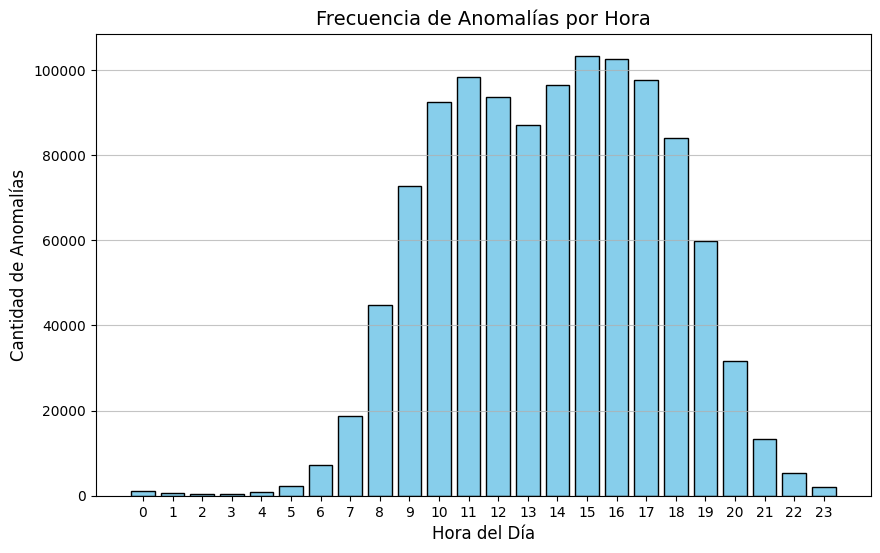

In [37]:
# Graficar anomalías por hora
plt.figure(figsize=(10, 6))
plt.bar(anomalies_by_hour_table['Hour'], anomalies_by_hour_table['Anomaly Count'], color='skyblue', edgecolor='k')
plt.title('Frecuencia de Anomalías por Hora', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Cantidad de Anomalías', fontsize=12)
plt.xticks(range(0, 24), fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.show()

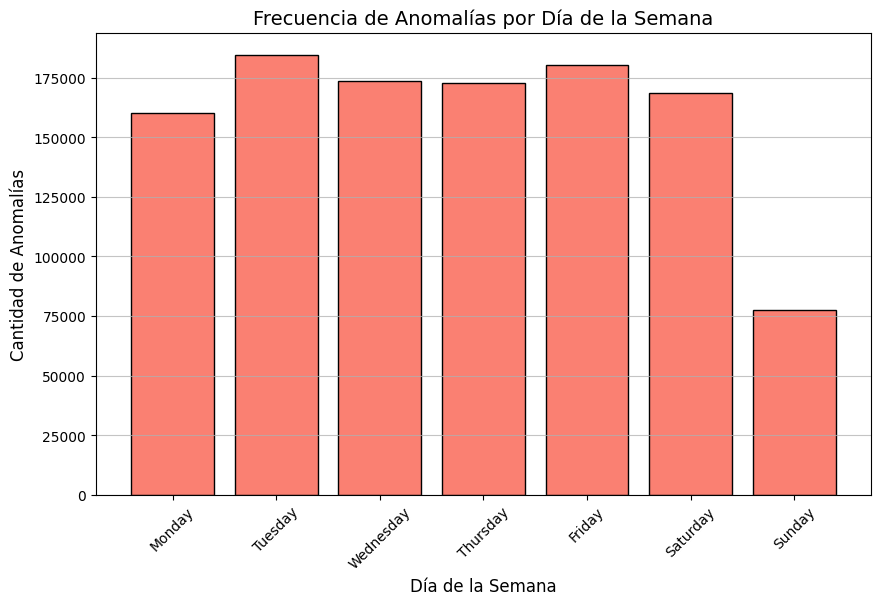

In [38]:
# Graficar anomalías por día de la semana
plt.figure(figsize=(10, 6))
plt.bar(anomalies_by_day_table['Day of Week'], anomalies_by_day_table['Anomaly Count'], color='salmon', edgecolor='k')
plt.title('Frecuencia de Anomalías por Día de la Semana', fontsize=14)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Cantidad de Anomalías', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.show()

###  Valores atipicos:
* Los picos con mayor actividad son enrtre las 10 y las 18 horas 
* Los días con mas anomalias son del martes al viernes

### Analisis de los debitos por mayor riesgo segun los resultados enteriores 

In [39]:
# Filtrar solo transacciones de tipo "DEBITO"
debit_transactions = data[data['transaction_type'] == "DEBITO"]

# 1. Análisis de "DEBITO" por usuarios específicos
debit_by_user = debit_transactions.groupby('user_id')['transaction_amount'].agg(['count', 'mean', 'max']).reset_index()
debit_by_user.columns = ['User ID', 'Debit Count', 'Average Amount', 'Max Amount']

# 2. Análisis de combinaciones de merchant_id y horarios en anomalías
# Filtrar anomalías y agrupar por merchant_id y hora
outliers_debit = outliers_details[outliers_details['transaction_type'] == "DEBITO"]
merchant_hour_analysis = outliers_debit.groupby(['merchant_id', 'hour']).size().reset_index(name='Anomaly Count')



In [40]:
# transacciones promedio por usuario 
debit_by_user

,User ID,Debit Count,Average Amount,Max Amount
0,000004f4a6f3ac93f454a5dc04b2a252,8,151.583603,713.334601
1,00000c80915f64c9bcbf1e85a2e5f3ec,1,118.889100,118.889100
2,0000183b7afadd73b835445207a602c4,5,45.177858,83.222370
3,00001b14c4e2e0e4d17e1ad81d45f52a,3,321.000571,380.445121
4,000020226aab8ce7a1126f94734966ed,1,273.444931,273.444931
...,...,...,...,...
1376583,ffffabf2248428818f6bf11e2e25b49e,8,240.750428,701.445691
1376584,ffffb01a2e2121c4411dcc66358e3767,1,701.445691,701.445691
1376585,ffffbe96808cdeaba25184e9f1edbaba,5,99.866844,297.222751
1376586,ffffed6a586baff30e8cd9f18a73290e,7,317.603739,713.334601


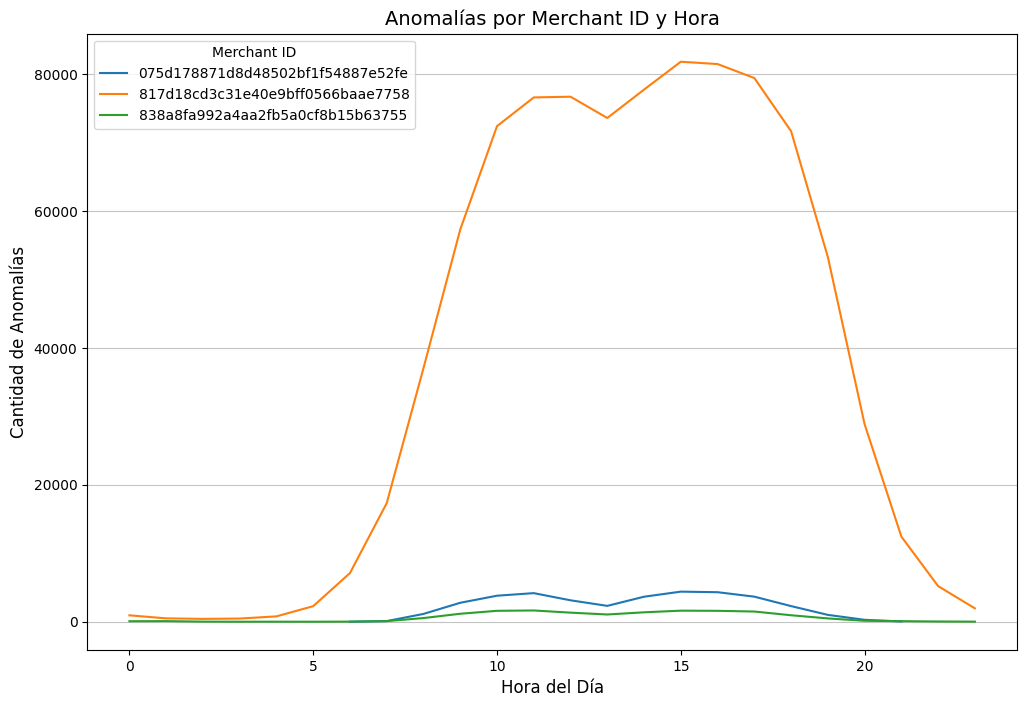

In [41]:
# Graficar anomalías por merchant_id y hora
plt.figure(figsize=(12, 8))
for merchant in merchant_hour_analysis['merchant_id'].unique():
    subset = merchant_hour_analysis[merchant_hour_analysis['merchant_id'] == merchant]
    plt.plot(subset['hour'], subset['Anomaly Count'], label=merchant)

plt.title('Anomalías por Merchant ID y Hora', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Cantidad de Anomalías', fontsize=12)
plt.legend(title='Merchant ID', fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [42]:
 # Identificar los comercios con mayor cantidad de anomalías
top_merchants_anomalies = merchant_hour_analysis.groupby('merchant_id').agg(
    total_anomalies=('Anomaly Count', 'sum'),
    alert_hours=('hour', lambda x: list(x))
).reset_index()

# Ordenar por la cantidad total de anomalías en orden descendente
top_merchants_anomalies = top_merchants_anomalies.sort_values(by='total_anomalies', ascending=False)
top_merchants_anomalies


,merchant_id,total_anomalies,alert_hours
1,817d18cd3c31e40e9bff0566baae7758,917434,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
0,075d178871d8d48502bf1f54887e52fe,37069,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1..."
2,838a8fa992a4aa2fb5a0cf8b15b63755,15390,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


## Los comercios con mayor cantidad de anómalias:
* el comercio con mayor anomalias se conoce como "817d18cd3c31e40e9bff0566baae7758"
* 

In [43]:
# Filtrar usuarios con entre 5 y 9 cuentas
users_with_5_to_9_accounts = accounts_per_user[(accounts_per_user >= 5) & (accounts_per_user <= 9)].index

# Filtrar transacciones de estos usuarios
transactions_5_to_9_accounts = data[data['user_id'].isin(users_with_5_to_9_accounts)]

# Calcular la dispersión (desviación estándar) de los montos para estos usuarios
dispersion_stats = transactions_5_to_9_accounts.groupby('user_id')['transaction_amount'].agg(['std', 'mean', 'count']).reset_index()

# Filtrar transacciones del comercio específico
transactions_specific_merchant = transactions_5_to_9_accounts[transactions_5_to_9_accounts['merchant_id'] == "817d18cd3c31e40e9bff0566baae7758"]

# Agrupar por hora para establecer picos puntuales
hourly_pico_analysis = transactions_specific_merchant.groupby(transactions_specific_merchant['transaction_date'].dt.hour)['transaction_amount'].agg(['count', 'mean']).reset_index()


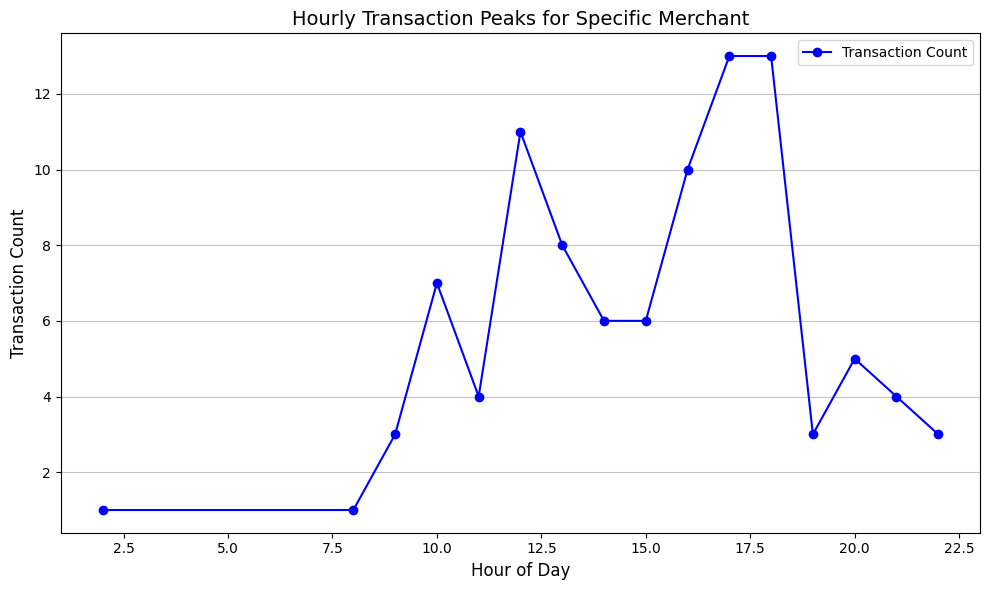

In [44]:
# Graficar los picos horarios para el comercio específico
plt.figure(figsize=(10, 6))
plt.plot(hourly_pico_analysis['transaction_date'], hourly_pico_analysis['count'], marker='o', label='Transaction Count', color='blue')
plt.title('Hourly Transaction Peaks for Specific Merchant', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [46]:
# Filtrar usuarios con entre 5 y 9 cuentas en `outliers_summary`
outliers_5_to_9_accounts = outliers_summary[outliers_summary.index.isin(users_with_5_to_9_accounts)]

# Filtrar transacciones atípicas para el comercio específico
outliers_specific_merchant = outliers_5_to_9_accounts[outliers_5_to_9_accounts.index.isin(
    transactions_specific_merchant['user_id'])]

# Resumen por hora para las transacciones atípicas de este comercio
outliers_specific_merchant_hours = transactions_specific_merchant[
    transactions_specific_merchant['user_id'].isin(outliers_specific_merchant.index)
]
hourly_outliers_pico_analysis = outliers_specific_merchant_hours.groupby(
    transactions_specific_merchant['transaction_date'].dt.hour
)['transaction_amount'].agg(['count', 'mean']).reset_index()




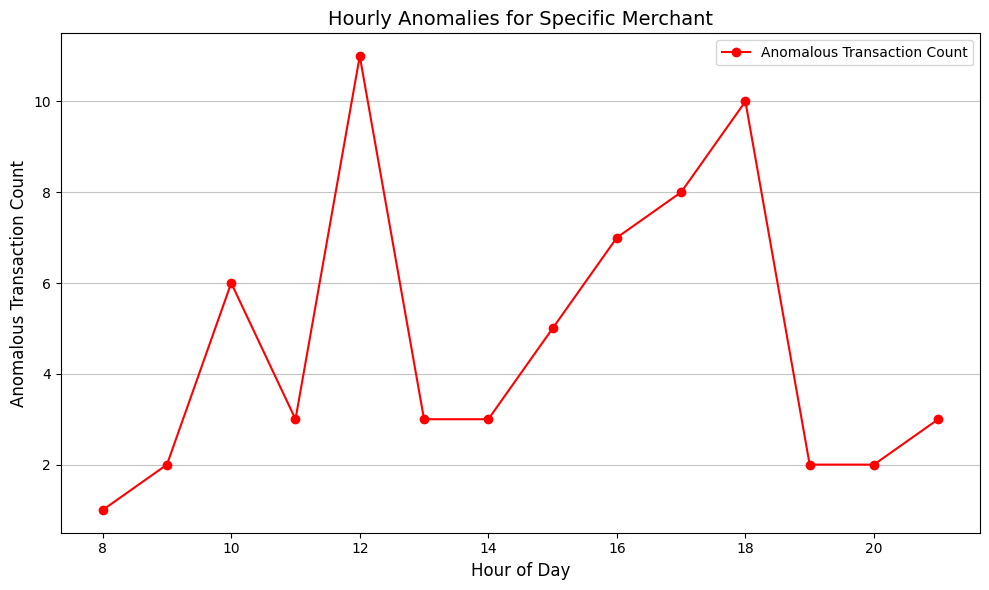

In [47]:
# Graficar los picos horarios de anomalías para el comercio específico que presetento anomalías
plt.figure(figsize=(10, 6))
plt.plot(hourly_outliers_pico_analysis['transaction_date'], hourly_outliers_pico_analysis['count'], marker='o', label='Anomalous Transaction Count', color='red')
plt.title('Hourly Anomalies for Specific Merchant', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Anomalous Transaction Count', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Resultados:
* Si comparamos los clientes que presetaron algunas anomalias en el análisis anterior se observa que a las 12 del dia y a 18 hores se concentra el mayor numero de transacciones anomalas , en los clientes con mayor numero de productos .
* Como recomendacion en un escenario real estas transacciones se deberían validar por topes o  complentar con configuraciones que permitan comporbar dicha alerta 

# Sandbox